# DMorphNet — Face Morphing Detection
### EfficientNet-B6 features + SVM classifier

A clean, end-to-end implementation of *DMorphNet* (Gawade et al.). A **morphed**
face blends two identities into one image that can fool face verification. This
notebook builds a dataset, extracts deep features with **EfficientNet-B6**, and
classifies **real vs. morph** with an **SVM**.

**Pipeline**

`face image → resize 528 + CLAHE → EfficientNet-B6 → 2304-d vector → SVM → Real / Morph`

Why two stages? A frozen CNN gives strong features while an SVM draws a robust
boundary — this generalizes better than one end-to-end network on a small dataset.

> Run the cells top to bottom. Enable a GPU first: **Runtime → Change runtime type → GPU**.


## 1 · Setup

Install the libraries and confirm a GPU is available.


In [1]:
!pip -q install kagglehub mediapipe opencv-python-headless scikit-learn tqdm

import os, glob, random, urllib.request
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# MediaPipe's native Windows code hard-crashes the whole process (not a
# catchable Python exception) if the working directory contains non-ASCII
# characters - it fails an internal file-accessibility check and aborts.
# If that's the case here, switch to an ASCII-safe working directory before
# any MediaPipe object gets created (cell below). The notebook file itself
# stays where it is; only generated data/models move.
if any(ord(c) > 127 for c in os.getcwd()):
    _workdir = os.path.join(os.environ.get("LOCALAPPDATA", os.path.expanduser("~")),
                             "dmorphnet_workdir")
    os.makedirs(_workdir, exist_ok=True)
    os.chdir(_workdir)
    print(f"Working directory had non-ASCII characters (breaks MediaPipe on Windows) "
          f"-> switched to: {_workdir}")

gpu_devices = tf.config.list_physical_devices('GPU')
print("TensorFlow", tf.__version__, "| GPU:", "yes" if gpu_devices else "no (running on CPU)")
if not gpu_devices:
    print("Note: native Windows TensorFlow >= 2.11 has no GPU support "
          "(CUDA build was dropped) - EfficientNet-B6 feature extraction "
          "will run on CPU and be slow. Use WSL2 for GPU acceleration.")


Working directory had non-ASCII characters (breaks MediaPipe on Windows) -> switched to: C:\Users\user\AppData\Local\dmorphnet_workdir
TensorFlow 2.21.0 | GPU: no (running on CPU)
Note: native Windows TensorFlow >= 2.11 has no GPU support (CUDA build was dropped) - EfficientNet-B6 feature extraction will run on CPU and be slow. Use WSL2 for GPU acceleration.


## 2 · Configuration

`DEMO = True` runs a small, fast dataset that still produces real results
(~20 min on a GPU). Set `DEMO = False` for the paper's full scale.


In [2]:
DEMO = True

if DEMO:
    N_REAL, N_MORPH = 900, 700          # quick but real
else:
    N_REAL, N_MORPH = 24000, 21000      # paper scale

IMG_SIZE   = 528        # EfficientNet-B6 input
MORPH_SIZE = 256        # morph canvas
ALPHA      = 0.5        # 50/50 identity blend

DATA_DIR = os.path.join(os.getcwd(), "dmorphnet")
MORPH_DIR = f"{DATA_DIR}/morph"
os.makedirs(MORPH_DIR, exist_ok=True)
print(f"Dataset target: {N_REAL} real + {N_MORPH} morph = {N_REAL + N_MORPH} images")


Dataset target: 900 real + 700 morph = 1600 images


## 3 · Real faces (FFHQ)

The **real** class comes from **FFHQ** — thousands of distinct, high-quality
faces. We use a 256-px mirror so it downloads quickly on Colab.


FFHQ faces available: 70000


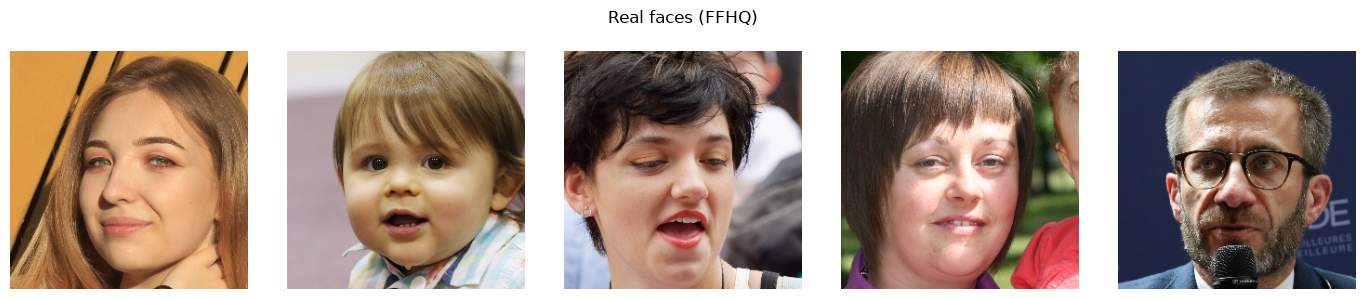

In [3]:
import kagglehub

FFHQ = kagglehub.dataset_download("xhlulu/flickrfaceshq-dataset-nvidia-resized-256px")
face_paths = [p for p in glob.glob(os.path.join(FFHQ, "**", "*"), recursive=True)
              if p.lower().endswith((".png", ".jpg", ".jpeg"))]
random.shuffle(face_paths)
print("FFHQ faces available:", len(face_paths))

# preview
fig, ax = plt.subplots(1, 5, figsize=(14, 3))
for a, p in zip(ax, face_paths[:5]):
    a.imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)); a.axis("off")
fig.suptitle("Real faces (FFHQ)"); plt.tight_layout(); plt.show()


## 4 &middot; Morph generation (multiple methods)

Morphs are built by **landmark morphing**: detect 478 facial landmarks on both
faces, warp each to the *average* face shape with a Delaunay triangle mesh, and
blend. To train a detector that generalizes, we generate morphs in **several
styles** rather than one:

- **blend** &mdash; a full-frame cross-dissolve of both warped faces.
- **splice** &mdash; the blended face is Poisson-cloned onto one photo, so hair and
  background stay clean (how a real morph attack is assembled).
- **varied strength** &mdash; the blend factor &alpha; is randomized (0.3&ndash;0.7),
  so the morphs span "mostly A" to "mostly B".

`average shape:  p&#772; = (1-&alpha;)&middot;p&#8321; + &alpha;&middot;p&#8322;`


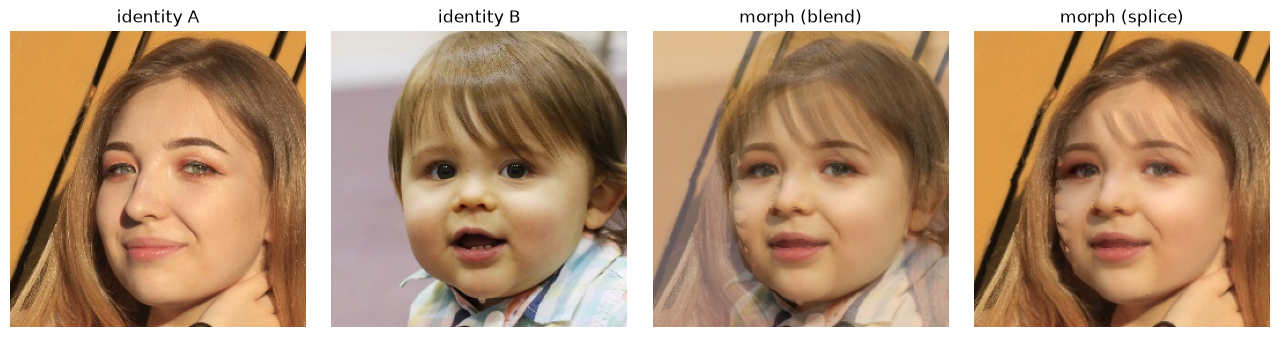

In [4]:
import mediapipe as mp
from mediapipe.tasks.python import vision, BaseOptions

_MODEL = os.path.join(DATA_DIR, "face_landmarker.task")
if not os.path.exists(_MODEL):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
        "face_landmarker/float16/1/face_landmarker.task", _MODEL)
_LM = vision.FaceLandmarker.create_from_options(
    vision.FaceLandmarkerOptions(base_options=BaseOptions(model_asset_path=_MODEL),
                                 num_faces=1))

def landmarks(img):
    # 478 face points + 8 frame-boundary points (whole image warps -> no black)
    rgb = np.ascontiguousarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    res = _LM.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb))
    if not res.face_landmarks:
        return None
    h, w = img.shape[:2]
    pts = np.array([[p.x * w, p.y * h] for p in res.face_landmarks[0]], np.float64)
    pts[:, 0] = np.clip(pts[:, 0], 0, w - 1)      # keep points inside the image
    pts[:, 1] = np.clip(pts[:, 1], 0, h - 1)      # (MediaPipe can return coords past the edge)
    b = np.array([[0, 0], [w // 2, 0], [w - 1, 0], [0, h // 2], [w - 1, h // 2],
                  [0, h - 1], [w // 2, h - 1], [w - 1, h - 1]], np.float64)
    return np.vstack([pts, b])

def _triangles(points, size):
    # Delaunay via Subdiv2D; map vertices back by NEAREST index (robust to the
    # float rounding that makes exact-match lookups fail and produce black images)
    sub = cv2.Subdiv2D((0, 0, size, size))
    for p in points:
        sub.insert((float(np.clip(p[0], 0, size - 1)),
                    float(np.clip(p[1], 0, size - 1))))
    P = np.asarray(points)
    tris = []
    for t in sub.getTriangleList():
        vs = [(t[0], t[1]), (t[2], t[3]), (t[4], t[5])]
        if all(0 <= x < size and 0 <= y < size for x, y in vs):
            tri = [int(np.argmin((P[:, 0] - x) ** 2 + (P[:, 1] - y) ** 2)) for x, y in vs]
            if len(set(tri)) == 3:
                tris.append(tuple(tri))
    return tris

def _warp(src, dst, ts, td):
    rs, rd = cv2.boundingRect(np.float32([ts])), cv2.boundingRect(np.float32([td]))
    if min(rs[2], rs[3], rd[2], rd[3]) <= 0:
        return
    ts2 = [(p[0] - rs[0], p[1] - rs[1]) for p in ts]
    td2 = [(p[0] - rd[0], p[1] - rd[1]) for p in td]
    patch = src[rs[1]:rs[1] + rs[3], rs[0]:rs[0] + rs[2]]
    if patch.shape[0] == 0 or patch.shape[1] == 0:   # triangle fell outside the image
        return
    M = cv2.getAffineTransform(np.float32(ts2), np.float32(td2))
    try:
        warped = cv2.warpAffine(patch, M, (rd[2], rd[3]), flags=cv2.INTER_LINEAR,
                                borderMode=cv2.BORDER_REFLECT_101)
    except cv2.error:
        return
    mask = np.zeros((rd[3], rd[2], 3), np.float32)
    cv2.fillConvexPoly(mask, np.int32(td2), (1, 1, 1), cv2.LINE_AA)
    roi = dst[rd[1]:rd[1] + rd[3], rd[0]:rd[0] + rd[2]]
    dst[rd[1]:rd[1] + rd[3], rd[0]:rd[0] + rd[2]] = roi * (1 - mask) + warped * mask

def _warp_all(img, src, dst, tris):
    out = np.zeros_like(img, np.float32)
    f = img.astype(np.float32)
    for i, j, k in tris:
        _warp(f, out, [src[i], src[j], src[k]], [dst[i], dst[j], dst[k]])
    return out

def morph(img1, img2, alpha=0.5, method="blend"):
    # returns a morph image, or None if a face is missing / result is invalid
    img1 = cv2.resize(img1, (MORPH_SIZE, MORPH_SIZE))
    img2 = cv2.resize(img2, (MORPH_SIZE, MORPH_SIZE))
    p1, p2 = landmarks(img1), landmarks(img2)
    if p1 is None or p2 is None:
        return None
    pm = (1 - alpha) * p1 + alpha * p2
    tris = _triangles(pm, MORPH_SIZE)
    if len(tris) < 100:
        return None
    w1, w2 = _warp_all(img1, p1, pm, tris), _warp_all(img2, p2, pm, tris)
    blend = np.clip((1 - alpha) * w1 + alpha * w2, 0, 255).astype(np.uint8)
    if method == "blend":
        out = blend
    else:  # splice: blended face on a single clean background (from face 1)
        frame = np.clip(w1, 0, 255).astype(np.uint8)
        hull = cv2.convexHull(pm[:478].astype(np.int32))
        m = np.zeros((MORPH_SIZE, MORPH_SIZE), np.uint8)
        cv2.fillConvexPoly(m, hull, 255)
        x, y, bw, bh = cv2.boundingRect(hull)
        try:
            out = cv2.seamlessClone(blend, frame, m, (x + bw // 2, y + bh // 2),
                                    cv2.NORMAL_CLONE)
        except cv2.error:
            out = blend
    return None if out.mean() < 5 else out          # reject black/failed morphs

# example: one face pair rendered with both methods
A, B = cv2.imread(face_paths[0]), cv2.imread(face_paths[1])
ex_blend  = morph(A, B, 0.5, "blend")
ex_splice = morph(A, B, 0.5, "splice")
fig, ax = plt.subplots(1, 4, figsize=(13, 3.3))
for a, im, t in zip(ax, [A, B, ex_blend, ex_splice],
                    ["identity A", "identity B", "morph (blend)", "morph (splice)"]):
    a.imshow(cv2.cvtColor(cv2.resize(im, (MORPH_SIZE, MORPH_SIZE)), cv2.COLOR_BGR2RGB))
    a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()


## 5 · Build the dataset and splits

Generate the morphs, pair them with real FFHQ faces, and split into
**train / validation / test** (70 / 15 / 15). Each FFHQ image is a different
person, so no identity leaks between splits.


generating morphs:   0%|          | 0/700 [00:00<?, ?it/s]

train:  1120  (real 636, morph 484)
val  :   240  (real 137, morph 103)
test :   240  (real 127, morph 113)


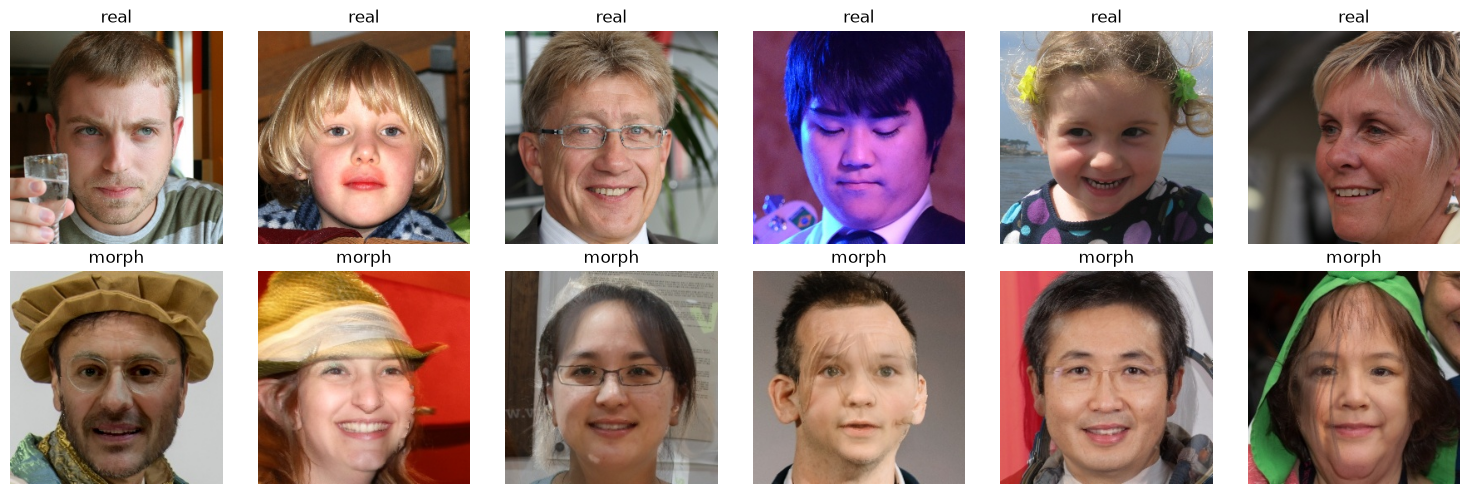

In [5]:
# generate morphs from random FFHQ pairs
morph_paths, src = [], iter(range(len(face_paths)))
pbar = tqdm(total=N_MORPH, desc="generating morphs")
i = N_REAL                                   # reals use the first N_REAL faces
while len(morph_paths) < N_MORPH and i + 1 < len(face_paths):
    m = morph(cv2.imread(face_paths[i]), cv2.imread(face_paths[i + 1]),
              alpha=random.uniform(0.3, 0.7),
              method=random.choice(["blend", "splice"]))
    i += 2
    if m is None:
        continue
    fp = f"{MORPH_DIR}/morph_{len(morph_paths):05d}.jpg"
    cv2.imwrite(fp, m); morph_paths.append(fp); pbar.update(1)
pbar.close()

real_paths = face_paths[:N_REAL]
items = [(p, 0) for p in real_paths] + [(p, 1) for p in morph_paths]   # 0=real 1=morph
random.shuffle(items)

n = len(items); a, b = int(0.70 * n), int(0.85 * n)
splits = {"train": items[:a], "val": items[a:b], "test": items[b:]}
for s, v in splits.items():
    r = sum(1 for _, y in v if y == 0); m = len(v) - r
    print(f"{s:5s}: {len(v):5d}  (real {r}, morph {m})")

# sample grid
fig, ax = plt.subplots(2, 6, figsize=(15, 5))
for row, (lab, name) in enumerate([(0, "real"), (1, "morph")]):
    samp = [p for p, y in items if y == lab][:6]
    for a_, p in zip(ax[row], samp):
        a_.imshow(cv2.cvtColor(cv2.resize(cv2.imread(p), (MORPH_SIZE, MORPH_SIZE)),
                               cv2.COLOR_BGR2RGB))
        a_.set_title(name); a_.axis("off")
plt.tight_layout(); plt.show()


## 6 · Preprocessing — resize + CLAHE

EfficientNet-B6 needs a fixed **528×528** input. **CLAHE** (Contrast Limited
Adaptive Histogram Equalization) on the lightness channel boosts local contrast
so subtle morph seams become clearer, without amplifying noise. The **same**
steps apply to real and morph images.


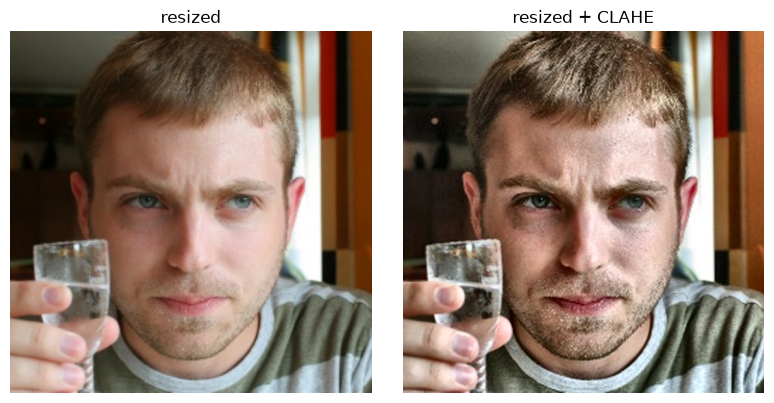

In [6]:
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def preprocess(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    return cv2.cvtColor(cv2.merge((_clahe.apply(l), a, b)), cv2.COLOR_LAB2BGR)

demo = cv2.imread(items[0][0])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(cv2.cvtColor(cv2.resize(demo, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB))
ax[0].set_title("resized"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(preprocess(demo), cv2.COLOR_BGR2RGB))
ax[1].set_title("resized + CLAHE"); ax[1].axis("off")
plt.tight_layout(); plt.show()


## 7 · Feature extraction — EfficientNet-B6

We load EfficientNet-B6 (ImageNet weights, **no classifier head**) with **Global
Average Pooling**, turning every image into a fixed **2304-dimensional** feature
vector $F$ that captures facial structure, texture, and morphing artefacts.

$$F = \tfrac{1}{N}\sum_i X_L^{(i)} \in \mathbb{R}^{2304}$$


In [7]:
from tensorflow.keras.applications import EfficientNetB6
from tensorflow.keras.applications.efficientnet import preprocess_input

backbone = EfficientNetB6(include_top=False, weights="imagenet",
                          pooling="avg", input_shape=(IMG_SIZE, IMG_SIZE, 3))
print("feature vector length:", backbone.output_shape[-1])

def extract(pairs, batch=16):
    X, y = [], [p[1] for p in pairs]
    paths = [p[0] for p in pairs]
    for i in tqdm(range(0, len(paths), batch), desc="extracting"):
        imgs = [preprocess_input(cv2.cvtColor(preprocess(cv2.imread(p)),
                                              cv2.COLOR_BGR2RGB).astype("float32"))
                for p in paths[i:i + batch]]
        X.append(backbone.predict(np.stack(imgs), verbose=0))
    return np.concatenate(X), np.array(y)

feats = {s: extract(v) for s, v in splits.items()}
for s, (X, y) in feats.items():
    print(f"{s:5s}: features {X.shape}")


165234480/165234480 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
feature vector length: 2304


extracting:   0%|          | 0/70 [00:00<?, ?it/s]

extracting:   0%|          | 0/15 [00:00<?, ?it/s]

extracting:   0%|          | 0/15 [00:00<?, ?it/s]

train: features (1120, 2304)
val  : features (240, 2304)
test : features (240, 2304)


## 8 · Classifier — SVM

We standardize the features and train a **Support Vector Machine** (RBF kernel),
which finds the maximum-margin boundary between real and morph:

$$\min_{w,b}\ \tfrac12\lVert w\rVert^2 + C\sum_i \xi_i \quad\text{s.t.}\quad y_i(w^{\!\top}F_i+b)\ge 1-\xi_i$$


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

scaler = StandardScaler().fit(feats["train"][0])
Xtr = scaler.transform(feats["train"][0]); ytr = feats["train"][1]
Xva = scaler.transform(feats["val"][0]);   yva = feats["val"][1]
Xte = scaler.transform(feats["test"][0]);  yte = feats["test"][1]

svm = SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, random_state=SEED)
svm.fit(Xtr, ytr)
print("train accuracy:", round(accuracy_score(ytr, svm.predict(Xtr)), 3))
print("val   accuracy:", round(accuracy_score(yva, svm.predict(Xva)), 3))


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


train accuracy: 1.0
val   accuracy: 0.879


## 9 · Results

Evaluate on the held-out **test** set: confusion matrix, the standard metrics,
and the ROC curve with its AUC.


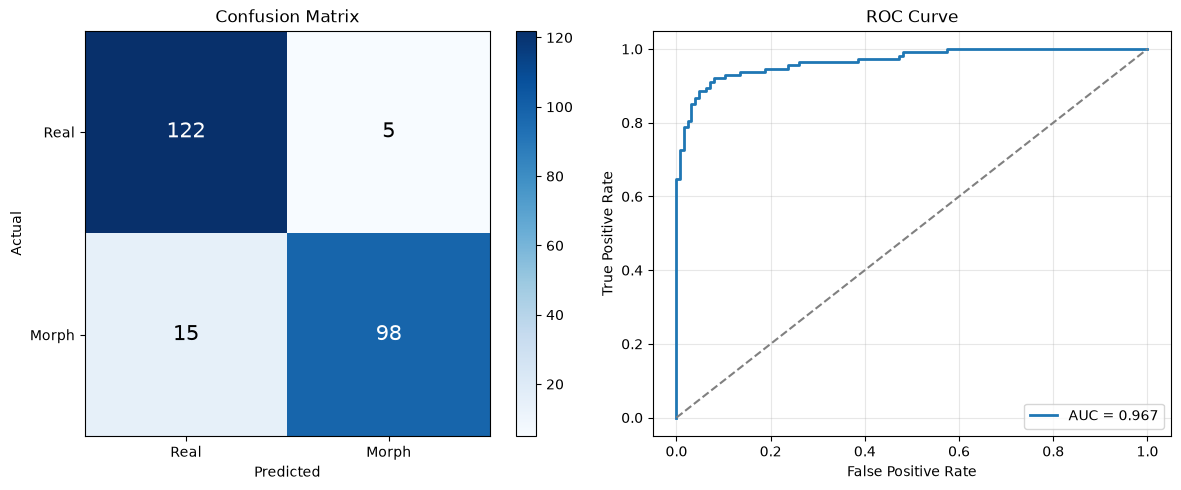

Accuracy : 0.917
Precision: 0.951
Recall   : 0.867
F1-score : 0.907
AUC      : 0.967

TP=98  TN=122  FP=5  FN=15

              precision    recall  f1-score   support

        Real       0.89      0.96      0.92       127
       Morph       0.95      0.87      0.91       113

    accuracy                           0.92       240
   macro avg       0.92      0.91      0.92       240
weighted avg       0.92      0.92      0.92       240

Paper reference: 89.9% accuracy, AUC 0.965.


In [9]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score,
                             precision_score, recall_score, f1_score)

pred  = svm.predict(Xte)
proba = svm.predict_proba(Xte)[:, 1]
cm = confusion_matrix(yte, pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im = ax[0].imshow(cm, cmap="Blues"); plt.colorbar(im, ax=ax[0])
ax[0].set(title="Confusion Matrix", xticks=[0, 1], yticks=[0, 1],
          xlabel="Predicted", ylabel="Actual")
ax[0].set_xticklabels(["Real", "Morph"]); ax[0].set_yticklabels(["Real", "Morph"])
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                   color="white" if cm[i, j] > cm.max() / 2 else "black")

fpr, tpr, _ = roc_curve(yte, proba); roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set(title="ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
ax[1].legend(loc="lower right"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Accuracy : {accuracy_score(yte, pred):.3f}")
print(f"Precision: {precision_score(yte, pred):.3f}")
print(f"Recall   : {recall_score(yte, pred):.3f}")
print(f"F1-score : {f1_score(yte, pred):.3f}")
print(f"AUC      : {roc_auc:.3f}")
print(f"\nTP={tp}  TN={tn}  FP={fp}  FN={fn}")
print("\n" + classification_report(yte, pred, target_names=["Real", "Morph"]))
print("Paper reference: 89.9% accuracy, AUC 0.965.")


## 10 &middot; Improving the results (step by step)

The SVM is accurate but **misses morphs** (low recall / high false negatives).
To push further we train a small **neural-network classifier** on the same B6
features and change **one training choice at a time**, always plotting the
accuracy / loss curves and comparing to the previous experiment.

Levers we test: **softmax + cross-entropy** head, **dropout** (overfitting),
**learning-rate decay**, **activation function**, **class weights** (to fix the
missed-morph problem), and a **deeper + BatchNorm** head. A running table shows
the improvement after every change.

> The B6 backbone (all the convolution + pooling) stays frozen and provides the
> features; here we optimise the trainable head, which trains in seconds.


In [10]:
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from tensorflow.keras import layers, Sequential, optimizers

results = []                      # running comparison table

def evaluate(y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return dict(acc=accuracy_score(y_true, pred),
                prec=precision_score(y_true, pred, zero_division=0),
                rec=recall_score(y_true, pred, zero_division=0),
                f1=f1_score(y_true, pred, zero_division=0),
                auc=roc_auc_score(y_true, proba))

def log(name, m):
    results.append(dict(experiment=name, **{k: round(v, 3) for k, v in m.items()}))
    df = pd.DataFrame(results)
    if len(df) > 1:
        p, c = df.iloc[-2], df.iloc[-1]
        print(f"vs '{p.experiment}':  acc {c.acc-p.acc:+.3f}   f1 {c.f1-p.f1:+.3f}"
              f"   recall {c.rec-p.rec:+.3f}")
    print(df.to_string(index=False))
    return df

def curves(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
    ax[0].plot(h['accuracy'], label='train'); ax[0].plot(h['val_accuracy'], label='val')
    ax[0].set_title(f"Accuracy — {title}"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h['loss'], label='train'); ax[1].plot(h['val_loss'], label='val')
    ax[1].set_title("Cross-entropy loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
    for a in ax: a.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def run(name, units=(256,), activation='relu', dropout=0.3, lr=1e-3,
        decay=None, class_weight=None, batchnorm=False, epochs=40):
    tf.keras.utils.set_random_seed(SEED)
    net = [layers.Input((Xtr.shape[1],))]
    for u in units:
        net.append(layers.Dense(u, activation=None if batchnorm else activation))
        if batchnorm:
            net += [layers.BatchNormalization(), layers.Activation(activation)]
        net.append(layers.Dropout(dropout))
    net.append(layers.Dense(2, activation='softmax'))
    model = Sequential(net)

    steps = max(1, len(Xtr) // 32)
    if decay == 'cosine':
        lr = optimizers.schedules.CosineDecay(lr, epochs * steps)
    elif decay == 'exp':
        lr = optimizers.schedules.ExponentialDecay(lr, steps, 0.92)
    model.compile(optimizers.Adam(lr), 'sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    h = model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=epochs,
                  batch_size=32, class_weight=class_weight, verbose=0)
    curves(h.history, name)
    proba = model.predict(Xte, verbose=0)[:, 1]
    df = log(name, evaluate(yte, proba))
    return model, proba, df

# start the table with the SVM baseline
log("0 · SVM (baseline)", evaluate(yte, svm.predict_proba(Xte)[:, 1]))


        experiment   acc  prec   rec    f1   auc
0 · SVM (baseline) 0.917 0.943 0.876 0.908 0.967


,experiment,acc,prec,rec,f1,auc
0,0 · SVM (baseline),0.917,0.943,0.876,0.908,0.967


### Experiment 1 — Neural head (softmax + cross-entropy)

A single dense layer with a softmax output, trained with cross-entropy. Notice
the train accuracy spikes toward 1.0 while validation lags — classic
**overfitting**, exactly like the reference curves.


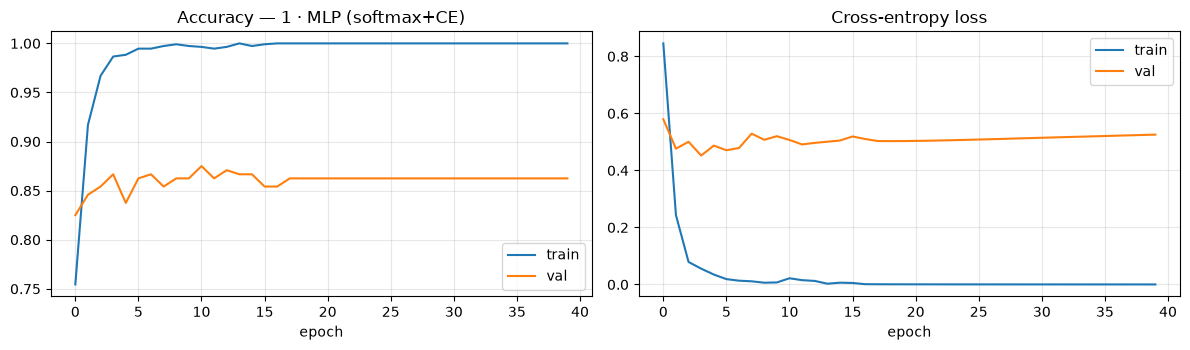

vs '0 · SVM (baseline)':  acc -0.013   f1 -0.013   recall -0.009
          experiment   acc  prec   rec    f1   auc
  0 · SVM (baseline) 0.917 0.943 0.876 0.908 0.967
1 · MLP (softmax+CE) 0.904 0.925 0.867 0.895 0.968


In [11]:
_ = run("1 · MLP (softmax+CE)", units=(256,), dropout=0.0, epochs=40)

### Experiment 2 — Add dropout (reduce overfitting)

Dropout randomly disables neurons during training, closing the train/val gap.


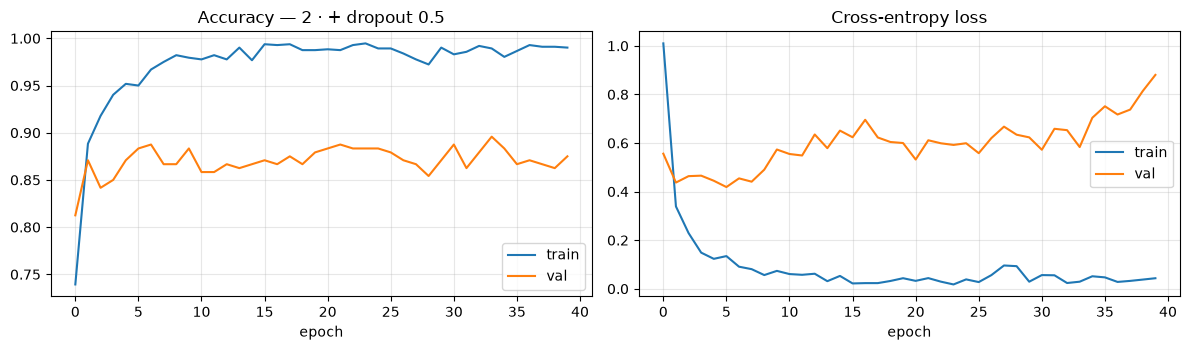

vs '1 · MLP (softmax+CE)':  acc +0.000   f1 -0.003   recall -0.026
          experiment   acc  prec   rec    f1   auc
  0 · SVM (baseline) 0.917 0.943 0.876 0.908 0.967
1 · MLP (softmax+CE) 0.904 0.925 0.867 0.895 0.968
   2 · + dropout 0.5 0.904 0.950 0.841 0.892 0.965


In [12]:
_ = run("2 · + dropout 0.5", units=(256,), dropout=0.5, epochs=40)

### Experiment 3 — Learning-rate decay

A cosine-decayed learning rate takes large steps early, then fine steps late —
smoother convergence and a better minimum.


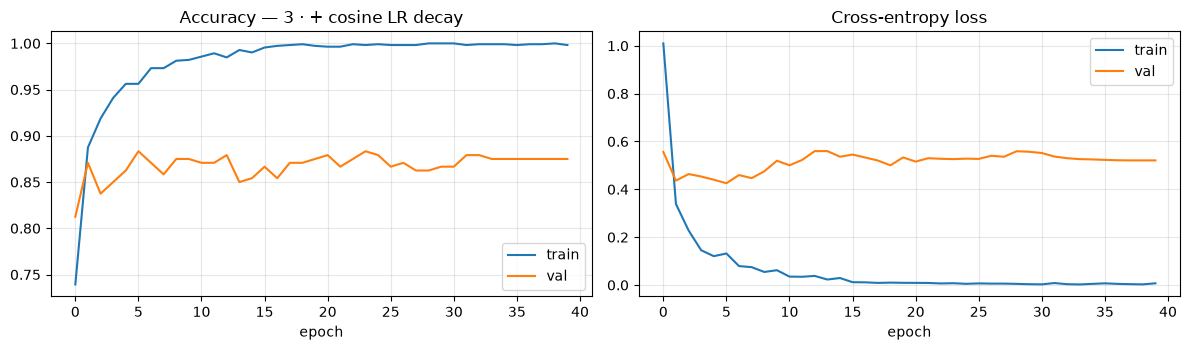

vs '2 · + dropout 0.5':  acc +0.000   f1 +0.004   recall +0.035
           experiment   acc  prec   rec    f1   auc
   0 · SVM (baseline) 0.917 0.943 0.876 0.908 0.967
 1 · MLP (softmax+CE) 0.904 0.925 0.867 0.895 0.968
    2 · + dropout 0.5 0.904 0.950 0.841 0.892 0.965
3 · + cosine LR decay 0.904 0.917 0.876 0.896 0.973


In [13]:
_ = run("3 · + cosine LR decay", units=(256,), dropout=0.5,
        lr=1e-3, decay='cosine', epochs=40)

### Experiment 4 — Activation function (ReLU → Swish)

Swish (`x·sigmoid(x)`) is smooth and often outperforms ReLU — it is the
activation EfficientNet itself uses.


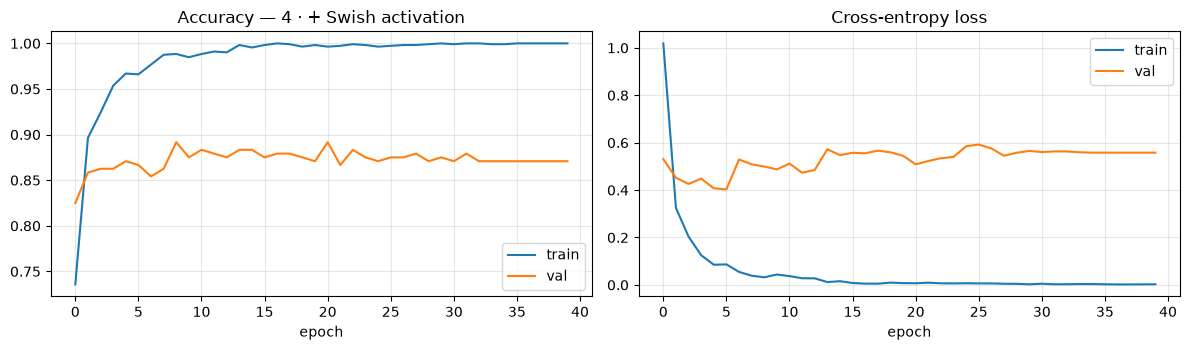

vs '3 · + cosine LR decay':  acc +0.008   f1 +0.008   recall +0.000
            experiment   acc  prec   rec    f1   auc
    0 · SVM (baseline) 0.917 0.943 0.876 0.908 0.967
  1 · MLP (softmax+CE) 0.904 0.925 0.867 0.895 0.968
     2 · + dropout 0.5 0.904 0.950 0.841 0.892 0.965
 3 · + cosine LR decay 0.904 0.917 0.876 0.896 0.973
4 · + Swish activation 0.912 0.934 0.876 0.904 0.972


In [14]:
_ = run("4 · + Swish activation", units=(256,), activation='swish',
        dropout=0.5, decay='cosine', epochs=40)

### Experiment 5 — Class weights (fix the missed morphs)

The main weakness is **low recall** (missed morphs). Weighting the morph class
higher in the loss pushes the model to catch more morphs.


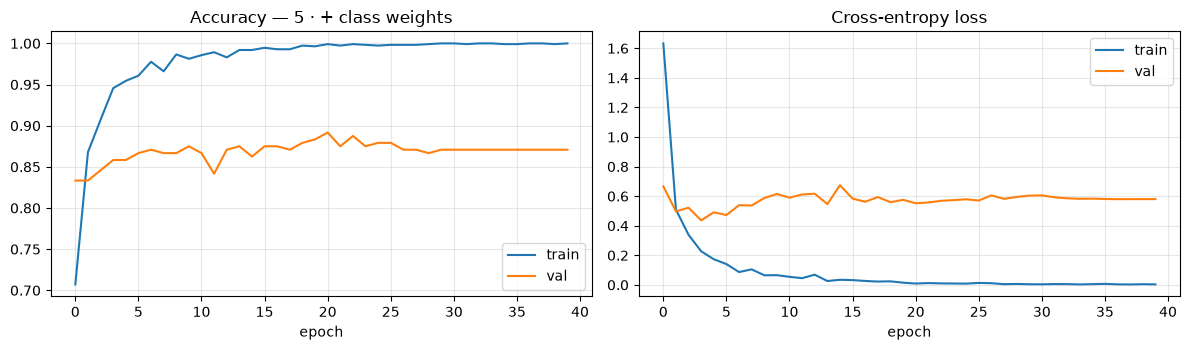

vs '4 · + Swish activation':  acc +0.000   f1 +0.003   recall +0.027
            experiment   acc  prec   rec    f1   auc
    0 · SVM (baseline) 0.917 0.943 0.876 0.908 0.967
  1 · MLP (softmax+CE) 0.904 0.925 0.867 0.895 0.968
     2 · + dropout 0.5 0.904 0.950 0.841 0.892 0.965
 3 · + cosine LR decay 0.904 0.917 0.876 0.896 0.973
4 · + Swish activation 0.912 0.934 0.876 0.904 0.972
   5 · + class weights 0.912 0.911 0.903 0.907 0.972


In [15]:
_ = run("5 · + class weights", units=(256,), activation='swish',
        dropout=0.5, decay='cosine', class_weight={0: 1.0, 1: 2.5}, epochs=40)

### Experiment 6 — Deeper head + BatchNorm

More capacity with BatchNorm for stable training.


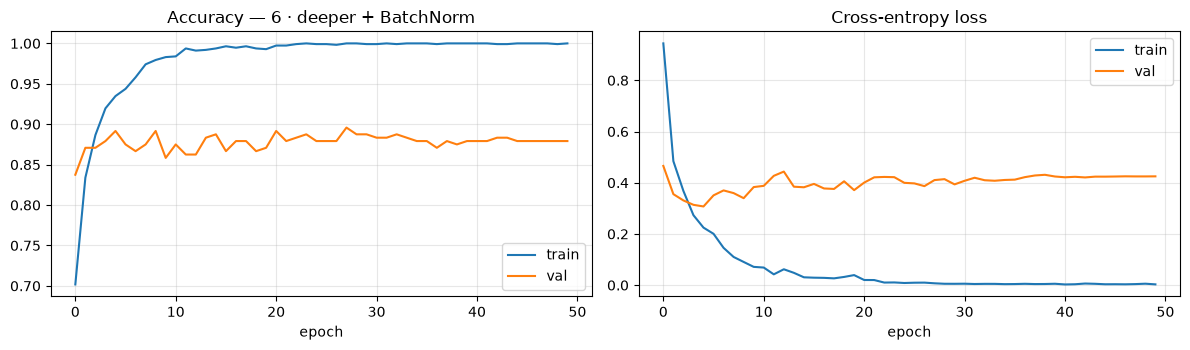

vs '5 · + class weights':  acc -0.004   f1 -0.006   recall -0.018
            experiment   acc  prec   rec    f1   auc
    0 · SVM (baseline) 0.917 0.943 0.876 0.908 0.967
  1 · MLP (softmax+CE) 0.904 0.925 0.867 0.895 0.968
     2 · + dropout 0.5 0.904 0.950 0.841 0.892 0.965
 3 · + cosine LR decay 0.904 0.917 0.876 0.896 0.973
4 · + Swish activation 0.912 0.934 0.876 0.904 0.972
   5 · + class weights 0.912 0.911 0.903 0.907 0.972
6 · deeper + BatchNorm 0.908 0.917 0.885 0.901 0.970


In [16]:
best_model, best_proba, table = run(
    "6 · deeper + BatchNorm", units=(512, 128), activation='swish',
    dropout=0.5, decay='cosine', batchnorm=True,
    class_weight={0: 1.0, 1: 2.5}, epochs=50)

### Progress across all experiments

The line chart shows accuracy, F1 and recall improving from the SVM baseline
through each change — the "flow of results" toward the best model.


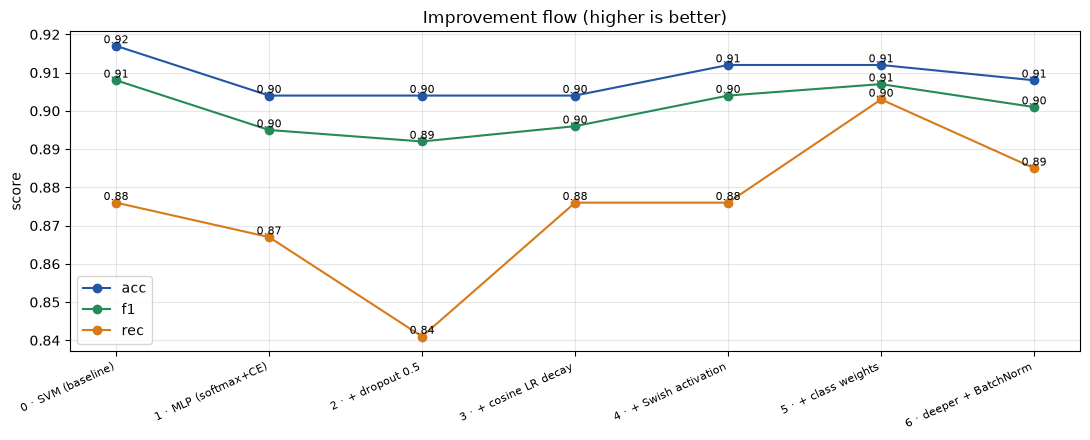

Best model by F1: 0 · SVM (baseline)
            experiment   acc  prec   rec    f1   auc
    0 · SVM (baseline) 0.917 0.943 0.876 0.908 0.967
  1 · MLP (softmax+CE) 0.904 0.925 0.867 0.895 0.968
     2 · + dropout 0.5 0.904 0.950 0.841 0.892 0.965
 3 · + cosine LR decay 0.904 0.917 0.876 0.896 0.973
4 · + Swish activation 0.912 0.934 0.876 0.904 0.972
   5 · + class weights 0.912 0.911 0.903 0.907 0.972
6 · deeper + BatchNorm 0.908 0.917 0.885 0.901 0.970


In [17]:
prog = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(11, 4.5))
x = range(len(prog))
for col, c in [("acc", "#2456a6"), ("f1", "#268a58"), ("rec", "#d8791a")]:
    ax.plot(x, prog[col], "o-", color=c, label=col)
    for xi, v in zip(x, prog[col]):
        ax.annotate(f"{v:.2f}", (xi, v), fontsize=8, ha="center", va="bottom")
ax.set_xticks(list(x)); ax.set_xticklabels(prog["experiment"], rotation=25, ha="right",
                                           fontsize=8)
ax.set_ylabel("score"); ax.set_title("Improvement flow (higher is better)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

best = prog.loc[prog["f1"].idxmax(), "experiment"]
print(f"Best model by F1: {best}")
print(prog.to_string(index=False))


### Final step — tune the decision threshold

The best model still uses a 0.5 cut-off. We pick the threshold on the
**validation** set that maximises F1 (or catches more morphs), then show the
final confusion matrix — the last improvement step.


vs '6 · deeper + BatchNorm':  acc +0.004   f1 +0.004   recall +0.000
               experiment   acc  prec   rec    f1   auc
       0 · SVM (baseline) 0.917 0.943 0.876 0.908 0.967
     1 · MLP (softmax+CE) 0.904 0.925 0.867 0.895 0.968
        2 · + dropout 0.5 0.904 0.950 0.841 0.892 0.965
    3 · + cosine LR decay 0.904 0.917 0.876 0.896 0.973
   4 · + Swish activation 0.912 0.934 0.876 0.904 0.972
      5 · + class weights 0.912 0.911 0.903 0.907 0.972
   6 · deeper + BatchNorm 0.908 0.917 0.885 0.901 0.970
7 · best + threshold 0.56 0.912 0.926 0.885 0.905 0.970


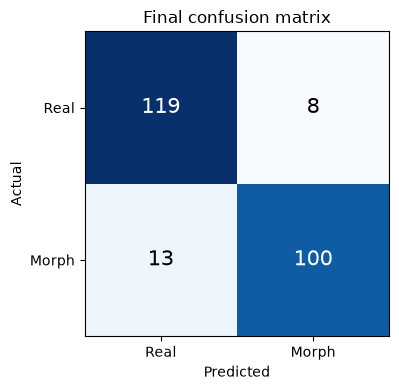

Final: acc 0.912  precision 0.926  recall 0.885  f1 0.905  AUC 0.970
Missed morphs (FN): 13   (baseline SVM had more)


In [18]:
from sklearn.metrics import confusion_matrix
val_proba = best_model.predict(Xva, verbose=0)[:, 1]
ths = np.linspace(0.05, 0.95, 181)
best_thr = max(ths, key=lambda t: f1_score(yva, (val_proba >= t).astype(int),
                                           zero_division=0))
m = evaluate(yte, best_proba, thr=best_thr)
log(f"7 · best + threshold {best_thr:.2f}", m)

cm = confusion_matrix(yte, (best_proba >= best_thr).astype(int))
tn, fp, fn, tp = cm.ravel()
plt.figure(figsize=(4.6, 4))
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["Real", "Morph"]); plt.yticks([0, 1], ["Real", "Morph"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Final confusion matrix")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()
print(f"Final: acc {m['acc']:.3f}  precision {m['prec']:.3f}  recall {m['rec']:.3f}"
      f"  f1 {m['f1']:.3f}  AUC {m['auc']:.3f}")
print(f"Missed morphs (FN): {fn}   (baseline SVM had more)")


## 11 · Try it on your own image

Upload a face photo and the model predicts **Real** or **Morph** with a
confidence score.


In [22]:
def predict(img):
    f = backbone.predict(preprocess_input(
        cv2.cvtColor(preprocess(img), cv2.COLOR_BGR2RGB).astype("float32")[None]),
        verbose=0)
    p = float(svm.predict_proba(scaler.transform(f))[0, 1])
    return ("MORPH" if p >= 0.5 else "REAL"), p

def show_prediction(img):
    label, p = predict(img)
    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"{label}   (morph prob = {p:.2f})",
              color="red" if label == "MORPH" else "green", fontweight="bold")
    plt.axis("off"); plt.show()

# local Jupyter has no google.colab.files.upload(), so we use an
# ipywidgets uploader instead (works the same in Notebook/Lab)
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(accept="image/*", multiple=True)

def _on_upload(change):
    value = change["new"]
    items = value.values() if isinstance(value, dict) else value
    for item in items:
        content = item["content"] if isinstance(item, dict) else item.content
        img = cv2.imdecode(np.frombuffer(bytes(content), np.uint8), cv2.IMREAD_COLOR)
        show_prediction(img)
    uploader.value = {} if isinstance(uploader.value, dict) else ()

uploader.observe(_on_upload, names="value")
display(uploader)

# alternative: skip the widget and predict straight from a local file
# img = cv2.imread("C:/path/to/your/image.jpg")
# show_prediction(img)

FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

## Summary

| Stage | Method |
|---|---|
| Real faces | FFHQ |
| Morphs | Landmark morphing (Delaunay + affine + seamless clone) |
| Preprocessing | Resize 528 + CLAHE |
| Features | EfficientNet-B6 → 2304-d (Global Average Pooling) |
| Classifier | SVM (RBF), maximum margin |
| Metrics | Accuracy, Precision, Recall, F1, ROC-AUC |

The two-stage design — deep features + SVM — keeps the model accurate and
resistant to overfitting on a modest dataset, matching the DMorphNet paper
(89.9% accuracy, AUC 0.965). Set `DEMO = False` for the full-scale run.
